# Practica - Unidad 3 (Parte 2): Procesamiento del Lenguaje

**Materia:** Procesamiento de Lenguaje Natural  
**Carrera:** TUIA - Universidad Nacional de Rosario  
**Docente:** Juan Pablo Manson

Esta segunda parte extiende la practica con los siguientes temas:

- **7.** Deteccion de idioma (Language Detection)
- **8.** Traduccion de texto (Language Translation)
- **9.** Sintesis de voz y TTS (Text-to-speech)
- **10.** Modelado de Topicos (Topic Modeling)

Al final encontraras ejercicios integradores que combinan tecnicas de ambas partes.

In [ ]:
# !pip install langdetect fasttext-langdetect deep-translator gTTS librosa bertopic scikit-learn sentence-transformers datasets

In [1]:
import warnings
warnings.filterwarnings('ignore')
import nltk
nltk.download('stopwords', quiet=True)

# ── Patch de compatibilidad: NumPy >= 2.0 (IDEMPOTENTE) ────────────────────
# NumPy 1.x: np.array(obj, copy=False)  →  "copiar solo si es necesario"
# NumPy 2.x: np.array(obj, copy=False)  →  "NUNCA copiar, error si hay que copiar"
# La migracion oficial es usar copy=None para el comportamiento anterior.
# Es IDEMPOTENTE: se puede ejecutar la celda muchas veces sin romper.
import numpy as np
if int(np.__version__.split('.')[0]) >= 2:
    # Guardamos el original UNA SOLA VEZ, en numpy mismo (sobrevive a re-runs)
    if not hasattr(np, '_array_orig_pre_patch'):
        np._array_orig_pre_patch = np.array

    _orig = np._array_orig_pre_patch  # SIEMPRE el original, nunca el parcheado

    def _np_array_compat(obj, *args, copy=None, **kwargs):
        # copy=False (1.x) ≡ copy=None (2.x): copiar solo si es necesario
        if copy is False:
            return _orig(obj, *args, copy=None, **kwargs)
        return _orig(obj, *args, copy=copy, **kwargs)

    np.array = _np_array_compat
    print(f"NumPy {np.__version__}: patch copy=False → copy=None aplicado (idempotente).")
else:
    print(f"NumPy {np.__version__}: no se necesita patch.")

NumPy 2.3.4: patch copy=False → copy=None aplicado (idempotente).


---

## 7. Deteccion de idioma (Language Detection)

### Fundamento teórico

La **deteccion de idioma** (Language Detection) identifica automaticamente el idioma de un texto. Es fundamental en sistemas NLP multilingues.

#### Metodos principales

1. **Frecuencia de n-gramas de caracteres:** Construye perfiles de idioma basados en la frecuencia de secuencias de caracteres y usa Naive Bayes para clasificar. Implementado en `langdetect`.

2. **Modelos estadisticos:** Clasificadores entrenados sobre grandes corpus etiquetados. Alcanzan 97%+ de precision en muchos idiomas.

3. **Modelos de aprendizaje profundo (FastText):** Facebook AI Research. Detecta hasta 176 idiomas con alta eficiencia incluso en textos cortos. Implementado en `ftlangdetect`.

#### Desafios

- **Textos muy cortos:** Pocas palabras pueden no ser suficientes.
- **Dialectos similares:** Serbio/croata, noruego/danes son dificiles de distinguir.
- **Code-switching:** Textos con mezcla de idiomas confunden a los modelos.
- **Variabilidad:** `langdetect` puede dar resultados distintos en ejecuciones sucesivas sobre el mismo texto (solucion: fijar semilla con `DetectorFactory.seed = 0`).

### Ejemplo practico 7.1: Deteccion con `langdetect`

`langdetect` usa n-gramas de caracteres y un clasificador Naive Bayes. Devuelve el codigo ISO 639-1 del idioma detectado (`'es'` para espanol, `'en'` para ingles, etc.).

In [3]:
# !pip install langdetect
from langdetect import detect, DetectorFactory

# Fijar semilla para reproducibilidad
DetectorFactory.seed = 0

textos = [
    "El procesamiento del lenguaje natural es fascinante.",
    "Natural language processing is fascinating.",
    "Le traitement du langage naturel est fascinant.",
    "Die Verarbeitung natuerlicher Sprache ist faszinierend.",
    "Il trattamento del linguaggio naturale e affascinante.",
    "O processamento de linguagem natural e fascinante.",
    "Dogal dil isleme buyuleyicidir.",
]

nombres = {
    'es': 'Espanol', 'en': 'Ingles', 'fr': 'Frances',
    'de': 'Aleman', 'it': 'Italiano', 'pt': 'Portugues', 'tr': 'Turco'
}

print(f"{'Texto':<52} {'Cod':>5} {'Idioma':>10}")
print("-" * 70)
for t in textos:
    cod = detect(t)
    nombre = nombres.get(cod, cod)
    truncado = t[:49] + '...' if len(t) > 49 else t
    print(f"{truncado:<52} {cod:>5} {nombre:>10}", len(t))

Texto                                                  Cod     Idioma
----------------------------------------------------------------------
El procesamiento del lenguaje natural es fascinan...    es    Espanol 52
Natural language processing is fascinating.             en     Ingles 43
Le traitement du langage naturel est fascinant.         fr    Frances 47
Die Verarbeitung natuerlicher Sprache ist faszini...    de     Aleman 55
Il trattamento del linguaggio naturale e affascin...    it   Italiano 54
O processamento de linguagem natural e fascinante...    pt  Portugues 50
Dogal dil isleme buyuleyicidir.                         tr      Turco 31


### Ejemplo practico 7.2: Probabilidades con `detect_langs`

Cuando el texto es ambiguo (mezcla de idiomas, terminos prestados, texto muy corto), es util obtener la **distribucion de probabilidades** sobre los idiomas posibles.

In [4]:
from langdetect import detect_langs, DetectorFactory
DetectorFactory.seed = 0

textos_ambiguos = [
    "Nunca mas, brother",            # mezcla es+en
    "El CEO presento el roadmap",    # es con anglicismos
    "OK",                            # muy corto
    "La vie en rose",                # fr con palabras en es
    "Hola Hello Bonjour",            # tres idiomas
]

for texto in textos_ambiguos:
    resultado = detect_langs(texto)
    print(f"Texto: '{texto}'")
    for lp in resultado:
        print(f"  {lp.lang}: {lp.prob:.3f}")
    print()

Texto: 'Nunca mas, brother'
  en: 1.000

Texto: 'El CEO presento el roadmap'
  es: 0.857
  pt: 0.143

Texto: 'OK'
  pt: 1.000

Texto: 'La vie en rose'
  es: 0.714
  af: 0.286

Texto: 'Hola Hello Bonjour'
  fi: 0.857
  it: 0.143



Observa como para textos ambiguos el modelo distribuye la probabilidad entre varios idiomas. El texto `'OK'` es un ejemplo extremo: al ser tan corto, puede asignarse a cualquier idioma.

### Ejemplo practico 7.3: Deteccion robusta con FastText (`ftlangdetect`)

`ftlangdetect` usa el modelo FastText de Facebook AI, capaz de detectar hasta **176 idiomas**. Generalmente mas consistente que `langdetect`, especialmente con textos cortos y dialectos.

In [5]:
# !pip install fasttext-langdetect
from ftlangdetect import detect

textos = [
    "Ich liebe die Natur und das Reisen.",
    "J'aime lire des livres et ecouter de la musique.",
    "Esto es una prueba en espanol.",
    "NLP is a subfield of artificial intelligence.",
    "机器学习正在改变世界。",
    "Bonjour, je suis tres content de vous rencontrer.",
]

print(f"{'Texto':<55} {'Idioma':>8} {'Score':>8}")
print("-" * 75)
for texto in textos:
    res = detect(text=texto, low_memory=True)
    truncado = texto[:52] + '...' if len(texto) > 52 else texto
    print(f"{truncado:<55} {res['lang']:>8} {res['score']:>8.4f}")

Texto                                                     Idioma    Score
---------------------------------------------------------------------------
Ich liebe die Natur und das Reisen.                           de   0.9998
J'aime lire des livres et ecouter de la musique.              fr   0.9932
Esto es una prueba en espanol.                                es   0.9709
NLP is a subfield of artificial intelligence.                 en   0.9144
机器学习正在改变世界。                                                   zh   0.9094
Bonjour, je suis tres content de vous rencontrer.             fr   0.9700


In [6]:
textos_ambiguos = [
    "Nunca mas, brother",            # mezcla es+en
    "El CEO presento el roadmap",    # es con anglicismos
    "OK",                            # muy corto
    "La vie en rose",                # fr con palabras en es
    "Hola Hello Bonjour",            # tres idiomas
]

for texto in textos_ambiguos:
    res = detect(text=texto, low_memory=True)
    truncado = texto[:52] + '...' if len(texto) > 52 else texto
    print(f"{truncado:<55} {res['lang']:>8} {res['score']:>8.4f}")

Nunca mas, brother                                            en   0.6767
El CEO presento el roadmap                                    es   0.8750
OK                                                            en   0.1245
La vie en rose                                                fr   0.4155
Hola Hello Bonjour                                            fr   0.6999


### Ejercicio 7.1: Analisis de tweets multilingues

Dado el siguiente conjunto de tweets:

```python
tweets = [
    "Increible partido de futbol anoche! #Argentina",
    "The weather is beautiful today! Going for a walk",
    "Paris est magnifique au printemps",
    "Das Buch ist sehr interessant, ich empfehle es!",
    "Mi pizza favorita es la de mozzarella",
    "Ciao a tutti! Come state oggi?",
    "Bom dia Brasil! Vamos que vamos!",
    "今日はとても良い天気ですね",
    "El nuevo album es un banger real",
    "I love you 3000 #Avengers",
]
```

**Tareas:**
1. Detecta el idioma de cada tweet usando `langdetect` y `ftlangdetect`.
2. Crea un DataFrame con columnas: `tweet`, `langdetect`, `ftlangdetect`, `coinciden`.
3. Identifica los casos donde los modelos discrepan y trata de explicar por que.

In [7]:
tweets = [
    "Increible partido de futbol anoche! #Argentina",
    "The weather is beautiful today! Going for a walk",
    "Paris est magnifique au printemps",
    "Das Buch ist sehr interessant, ich empfehle es!",
    "Mi pizza favorita es la de mozzarella",
    "Ciao a tutti! Come state oggi?",
    "Bom dia Brasil! Vamos que vamos!",
    "今日はとても良い天気ですね",
    "El nuevo album es un banger real",
    "I love you 3000 #Avengers",
]

In [9]:
#1. Detecta el idioma de cada tweet usando `langdetect` y `ftlangdetect`.
#2. Crea un DataFrame con columnas: `tweet`, `langdetect`, `ftlangdetect`, `coinciden`.

import pandas as pd
from ftlangdetect import detect
from langdetect import detect_langs, DetectorFactory
DetectorFactory.seed = 0


df = pd.DataFrame(tweets, columns=['tweet'])
df['langdetect'] = df['tweet'].apply(lambda x: detect_langs(x)[0].lang)
df['ftlangdetect'] = df['tweet'].apply(lambda x: detect(x)['lang'])
df['coinciden'] = df['langdetect'] == df['ftlangdetect']
print(df)

                                              tweet langdetect ftlangdetect  \
0    Increible partido de futbol anoche! #Argentina         es           es   
1  The weather is beautiful today! Going for a walk         en           en   
2                 Paris est magnifique au printemps         fr           fr   
3   Das Buch ist sehr interessant, ich empfehle es!         de           de   
4             Mi pizza favorita es la de mozzarella         it           es   
5                    Ciao a tutti! Come state oggi?         it           it   
6                  Bom dia Brasil! Vamos que vamos!         pt           pt   
7                                     今日はとても良い天気ですね         ja           ja   
8                  El nuevo album es un banger real         es           es   
9                         I love you 3000 #Avengers         no           en   

   coinciden  
0       True  
1       True  
2       True  
3       True  
4      False  
5       True  
6       True  
7       Tr

### Ejercicio 7.2: Detector robusto con manejo de errores

Implementa la funcion `detectar_idioma_robusto(textos)` que:

1. Para cada texto, use `detect_langs()` para obtener las probabilidades.
2. Si la probabilidad mas alta es menor a `0.7`, clasifique el texto como `'ambiguo'`.
3. Si el texto tiene menos de 5 palabras, agregue la advertencia `'[texto corto]'`.
4. Devuelva un DataFrame con columnas: `texto`, `idioma`, `confianza`, `advertencia`.
5. Muestre un grafico con la distribucion de idiomas detectados.

Prueba con:
```python
corpus = [
    "La inteligencia artificial esta transformando la industria tecnologica.",
    "Machine learning models require large amounts of training data.",
    "Les reseaux de neurones profonds revolutionnent l'IA.",
    "Hola",
    "Ok",
    "Buenos dias! How are you today?",
    "El modelo BERT fue desarrollado por Google en 2018.",
    "GPT-4 is OpenAI's most advanced language model.",
]
```

---

## 8. Traduccion de texto (Language Translation)

### Fundamento teorico

La **traduccion automatica** convierte texto de un idioma origen a un idioma destino. Ha evolucionado significativamente:

| Enfoque | Descripcion | Era |
|---------|-------------|-----|
| **RBMT** (Rule-Based MT) | Diccionarios y reglas linguisticas | 1950-1990 |
| **EBMT** (Example-Based MT) | Traduccion por analogia con corpus bilingue | 1980-2000 |
| **SMT** (Statistical MT) | Modelos probabilisticos sobre corpus paralelos | 1990-2014 |
| **NMT** (Neural MT) | Transformers encoder-decoder (seq2seq) | 2014-presente |

#### NMT con Transformers (estado del arte)

Los modelos **Helsinki-NLP/MarianMT** de HuggingFace son modelos NMT preentrenados que cubren cientos de pares de idiomas:
- `Helsinki-NLP/opus-mt-es-en`: Espanol → Ingles
- `Helsinki-NLP/opus-mt-en-es`: Ingles → Espanol
- `Helsinki-NLP/opus-mt-es-fr`: Espanol → Frances

#### Librerias y servicios

- **`transformers`** (HuggingFace): Acceso directo a modelos NMT como MarianMT.
- **`deep-translator`**: Interfaz unificada para multiples APIs (Google, MyMemory, Linguee, etc.).

### Ejemplo practico 8.1: Traduccion NMT con MarianMT

In [10]:
from transformers import MarianMTModel, MarianTokenizer

def traducir_marian(textos, modelo_nombre):
    """Traduce una lista de textos con un modelo MarianMT."""
    tokenizer = MarianTokenizer.from_pretrained(modelo_nombre)
    model = MarianMTModel.from_pretrained(modelo_nombre)
    inputs = tokenizer(textos, return_tensors='pt', padding=True, truncation=True)
    outputs = model.generate(**inputs)
    return tokenizer.batch_decode(outputs, skip_special_tokens=True)

# Espanol → Ingles
textos_es = [
    "Me gusta aprender procesamiento de lenguaje natural.",
    "La inteligencia artificial esta cambiando el mundo.",
    "Los modelos de lenguaje son herramientas muy poderosas.",
    "El aprendizaje profundo requiere grandes volumenes de datos.",
]

print("=== Espanol → Ingles (opus-mt-es-en) ===")
traducciones_en = traducir_marian(textos_es, 'Helsinki-NLP/opus-mt-es-en')
for es, en in zip(textos_es, traducciones_en):
    print(f"ES: {es}")
    print(f"EN: {en}")
    print()

# Ingles → Espanol
textos_en = [
    "Artificial intelligence is revolutionizing healthcare.",
    "Neural networks learn patterns from large datasets.",
]
print("=== Ingles → Espanol (opus-mt-en-es) ===")
traducciones_es = traducir_marian(textos_en, 'Helsinki-NLP/opus-mt-en-es')
for en, es in zip(textos_en, traducciones_es):
    print(f"EN: {en}")
    print(f"ES: {es}")
    print()

=== Espanol → Ingles (opus-mt-es-en) ===


tokenizer_config.json:   0%|          | 0.00/44.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/826k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/802k [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/312M [00:00<?, ?B/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

EN: Artificial intelligence is revolutionizing healthcare.
ES: La inteligencia artificial está revolucionando la salud.

EN: Neural networks learn patterns from large datasets.
ES: Las redes neuronales aprenden patrones de grandes conjuntos de datos.



### Ejemplo practico 8.2: Traduccion con servicios externos (`deep-translator`)

`deep-translator` proporciona una interfaz unificada para acceder a multiples servicios de traduccion via API. Servicios como GoogleTranslator y MyMemoryTranslator son gratuitos y no requieren API key.

In [13]:
# !pip install deep-translator
from deep_translator import GoogleTranslator, MyMemoryTranslator

print("=== GoogleTranslator (deteccion automatica de origen) ===")
ejemplos = [
    ("auto", "es", "Artificial intelligence is transforming industries."),
    ("auto", "en", "La inteligencia artificial transforma las industrias."),
    ("auto", "de", "Machine learning is a subset of AI."),
    ("auto", "fr", "El aprendizaje automatico es fascinante."),
]

for origen, destino, texto in ejemplos:
    try:
        trad = GoogleTranslator(source=origen, target=destino).translate(texto)
        print(f"[{origen}→{destino}] {texto}")
        print(f"           → {trad}")
        print()
    except Exception as e:
        print(f"Error: {e}")



=== GoogleTranslator (deteccion automatica de origen) ===
[auto→es] Artificial intelligence is transforming industries.
           → La inteligencia artificial está transformando las industrias.

[auto→en] La inteligencia artificial transforma las industrias.
           → Artificial intelligence transforms industries.

[auto→de] Machine learning is a subset of AI.
           → Maschinelles Lernen ist eine Teilmenge der KI.

[auto→fr] El aprendizaje automatico es fascinante.
           → L’apprentissage automatique est fascinant.



In [16]:
print("=== MyMemoryTranslator (100% gratuito, sin API key) ===")
try:
    texto = "Natural language processing enables computers to understand human language."
    trad = MyMemoryTranslator(source='en-US', target='es-CO').translate(texto)
    print(f"EN: {texto}")
    print(f"ES: {trad}")
except Exception as e:
    print(f"Error con MyMemory: {e}")

=== MyMemoryTranslator (100% gratuito, sin API key) ===
EN: Natural language processing enables computers to understand human language.
ES: El procesamiento del lenguaje natural permite a las computadoras comprender el lenguaje humano.


### Ejemplo practico 8.3: Pipeline deteccion + traduccion

Combinamos deteccion de idioma y traduccion para normalizar textos multilingues a un idioma comun.

In [17]:
from langdetect import detect, DetectorFactory
from deep_translator import GoogleTranslator
import pandas as pd

DetectorFactory.seed = 0

def pipeline_deteccion_traduccion(textos, idioma_destino='es'):
    """Detecta el idioma de cada texto y lo traduce al idioma destino si es diferente."""
    resultados = []
    for texto in textos:
        try:
            idioma_origen = detect(texto)
            if idioma_origen == idioma_destino:
                traduccion = texto
                traducido = False
            else:
                traduccion = GoogleTranslator(
                    source=idioma_origen, target=idioma_destino
                ).translate(texto)
                traducido = True
            resultados.append({
                'idioma': idioma_origen,
                'texto_original': texto,
                'texto_es': traduccion,
                'traducido': traducido
            })
        except Exception as e:
            resultados.append({
                'idioma': 'error', 'texto_original': texto,
                'texto_es': str(e), 'traducido': False
            })
    return pd.DataFrame(resultados)

# Resenas de un producto en distintos idiomas
resenas = [
    "This product is absolutely amazing! Best purchase ever.",
    "Das Produkt ist von sehr guter Qualitat. Ich bin sehr zufrieden.",
    "Ce produit est excellent, je le recommande vivement!",
    "Excelente producto, muy buena calidad y envio rapido.",
    "O produto chegou rapido e funciona perfeitamente.",
    "Il prodotto e ottimo, consegna velocissima.",
]

df = pipeline_deteccion_traduccion(resenas)
print("Pipeline: Deteccion + Traduccion al Espanol")
print("=" * 65)
for _, row in df.iterrows():
    status = "TRADUCIDO" if row['traducido'] else "YA EN ES"
    print(f"[{row['idioma']}] {status}")
    print(f"  Original: {row['texto_original'][:65]}")
    print(f"  Espanol:  {row['texto_es'][:65]}")
    print()

Pipeline: Deteccion + Traduccion al Espanol
[en] TRADUCIDO
  Original: This product is absolutely amazing! Best purchase ever.
  Espanol:  ¡Este producto es absolutamente increíble! La mejor compra jamás 

[de] TRADUCIDO
  Original: Das Produkt ist von sehr guter Qualitat. Ich bin sehr zufrieden.
  Espanol:  El producto es de muy buena calidad. Estoy muy satisfecho.

[fr] TRADUCIDO
  Original: Ce produit est excellent, je le recommande vivement!
  Espanol:  Este producto es excelente, lo recomiendo mucho!

[es] YA EN ES
  Original: Excelente producto, muy buena calidad y envio rapido.
  Espanol:  Excelente producto, muy buena calidad y envio rapido.

[pt] TRADUCIDO
  Original: O produto chegou rapido e funciona perfeitamente.
  Espanol:  El producto llegó rápido y funciona perfectamente.

[it] TRADUCIDO
  Original: Il prodotto e ottimo, consegna velocissima.
  Espanol:  El producto es excelente, entrega muy rápida.



### Ejercicio 8.1: Traduccion de un abstract cientifico

Dado el siguiente abstract en ingles:

```python
abstract = """
Large language models have demonstrated remarkable capabilities in natural language
understanding and generation. These models, trained on vast corpora of text data,
can perform tasks including translation, summarization, question answering, and code
generation. However, challenges remain in areas such as factual accuracy, reasoning,
and computational efficiency. This paper presents a survey of recent advances and
identifies key open problems for future investigation.
"""
```

**Tareas:**
1. Traduce el abstract al espanol usando MarianMT (`Helsinki-NLP/opus-mt-en-es`).
2. Traduce al frances usando `GoogleTranslator`.
3. Aplica **NER con spaCy** al texto traducido al espanol. ¿Que entidades detecta?
4. Compara la fluidez de las dos traducciones al espanol subjetivamente.

In [18]:
abstract = """
Large language models have demonstrated remarkable capabilities in natural language
understanding and generation. These models, trained on vast corpora of text data,
can perform tasks including translation, summarization, question answering, and code
generation. However, challenges remain in areas such as factual accuracy, reasoning,
and computational efficiency. This paper presents a survey of recent advances and
identifies key open problems for future investigation.
"""

In [20]:
#1. Traduce el abstract al espanol usando MarianMT (`Helsinki-NLP/opus-mt-en-es`).
traduccion_abstract = traducir_marian([abstract], 'Helsinki-NLP/opus-mt-en-es')[0]
print("=== Abstract Original (Ingles) ===")
print(abstract)
print("\n=== Abstract Traducido (Espanol) ===")
# dividir el texto en sentences para mejor legibilidad
sentences = traduccion_abstract.split('. ')
for s in sentences:
    print(s.strip() + ('.' if not s.endswith('.') else ''))
    

Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


=== Abstract Original (Ingles) ===

Large language models have demonstrated remarkable capabilities in natural language
understanding and generation. These models, trained on vast corpora of text data,
can perform tasks including translation, summarization, question answering, and code
generation. However, challenges remain in areas such as factual accuracy, reasoning,
and computational efficiency. This paper presents a survey of recent advances and
identifies key open problems for future investigation.


=== Abstract Traducido (Espanol) ===
Los grandes modelos lingüísticos han demostrado capacidades notables en la comprensión y generación natural del lenguaje.
Estos modelos, entrenados en vastos cuerpos de datos de texto, pueden realizar tareas incluyendo traducción, resumen, respuesta a preguntas y generación de código.
Sin embargo, persisten desafíos en áreas tales como exactitud fáctica, razonamiento y eficiencia computacional.


In [21]:
#2. Traduce al frances usando `GoogleTranslator`.
try:
    traduccion_fr = GoogleTranslator(source='en', target='fr').translate(abstract)
    print("\n=== Abstract Traducido (Frances) ===")
    sentences_fr = traduccion_fr.split('. ')
    for s in sentences_fr:
        print(s.strip() + ('.' if not s.endswith('.') else ''))
except Exception as e:
    print(f"Error al traducir al frances: {e}")


=== Abstract Traducido (Frances) ===
Les grands modèles de langage ont démontré des capacités remarquables en langage naturel
compréhension et génération.
Ces modèles, formés sur de vastes corpus de données textuelles,
peut effectuer des tâches telles que la traduction, le résumé, la réponse aux questions et le code
génération.
Toutefois, des défis subsistent dans des domaines tels que l'exactitude des faits, le raisonnement,
et l'efficacité informatique.
Cet article présente une étude des avancées récentes et
identifie les principaux problèmes ouverts pour une enquête future.


### Ejercicio 8.2: Back-translation y comparacion de calidad

Usa las siguientes frases en espanol:

```python
frases_es = [
    "No se si lo que me dijo fue en serio o en broma.",
    "Las redes neuronales profundas aprenden representaciones jerarquicas.",
    "Ayer vi a Maria en el parque con su perro.",
    "El modelo BERT fue desarrollado por Google en 2018.",
    "La bolsa de valores reacciono con fuertes caidas.",
]
```

**Tareas:**
1. Traduce cada frase al ingles con MarianMT y con GoogleTranslator.
2. Muestra los resultados en una tabla comparativa.
3. Aplica **back-translation**: traduce la version en ingles (de GoogleTranslator) de vuelta al espanol. ¿Que tan cerca esta del original?
4. Indica cual traduccion te parece mas precisa en cada caso.

---

## 9. Sintesis de voz y TTS (Text-to-speech)

### Fundamento teorico

La **sintesis de voz** (Text-to-Speech, TTS) convierte texto escrito en voz hablada. Es fundamental en asistentes virtuales, lectores de pantalla y sistemas de accesibilidad.

#### Proceso de sintesis de voz

1. **Preprocesamiento de texto:** Normalizacion (abreviaturas, numeros, signos de puntuacion) y conversion a representacion fonetica (grafemas → fonemas).

2. **Generacion de sonido:**
   - **Sintesis por concatenacion:** Ensambla fragmentos de voz humana pregrabados.
   - **Sintesis parametrica:** Usa modelos matematicos (HMM, DNN) para generar la senal.
   - **Sintesis neuronal (deep learning):** Redes como Tacotron o WaveNet generan voz muy natural.

3. **Post-procesamiento:** Ajuste de tono, velocidad y naturalidad.

#### Librerias en Python

| Libreria | Descripcion | Conexion |
|----------|-------------|----------|
| `gTTS` | Google TTS (neuronal, alta calidad) | Online |
| `pyttsx3` | Motores de voz del sistema operativo | Offline |
| `Coqui TTS` | Modelos neuronales open source | Offline |

> **Nota:** `gTTS` requiere conexion a internet ya que el procesamiento se realiza en los servidores de Google.

### Ejemplo practico 9.1: TTS basico con gTTS

In [22]:
# !pip install gTTS
from gtts import gTTS
from IPython.display import Audio, display

# Texto en espanol
texto = "Bienvenidos al curso de Procesamiento de Lenguaje Natural. Hoy aprenderemos sobre sintesis de voz."
tts = gTTS(text=texto, lang='es', slow=False)
tts.save("bienvenida.mp3")
print("Audio guardado: bienvenida.mp3")
display(Audio("bienvenida.mp3"))

# Multiples idiomas
frases = [
    ('es', "Buenos dias. Como estan todos hoy?"),
    ('en', "Good morning. How is everyone doing today?"),
    ('fr', "Bonjour. Comment allez-vous aujourd'hui?"),
    ('de', "Guten Morgen. Wie geht es Ihnen heute?"),
    ('it', "Buongiorno. Come state tutti oggi?"),
]

print("\nGenerando audios en multiples idiomas:")
for lang, frase in frases:
    tts = gTTS(text=frase, lang=lang, slow=False)
    fname = f"saludo_{lang}.mp3"
    tts.save(fname)
    print(f"  [{lang}] '{frase[:50]}' → {fname}")

Audio guardado: bienvenida.mp3



Generando audios en multiples idiomas:
  [es] 'Buenos dias. Como estan todos hoy?' → saludo_es.mp3
  [en] 'Good morning. How is everyone doing today?' → saludo_en.mp3
  [fr] 'Bonjour. Comment allez-vous aujourd'hui?' → saludo_fr.mp3
  [de] 'Guten Morgen. Wie geht es Ihnen heute?' → saludo_de.mp3
  [it] 'Buongiorno. Come state tutti oggi?' → saludo_it.mp3


### Ejemplo practico 9.2: Reproduccion y visualizacion del audio

Usamos `librosa` para analizar el audio sintetizado: **forma de onda** (amplitud en el tiempo) y **espectrograma** (distribucion de frecuencias en el tiempo).

Texto: El procesamiento del lenguaje natural permite que las computadoras entiendan y generen lenguaje humano de forma automatica.


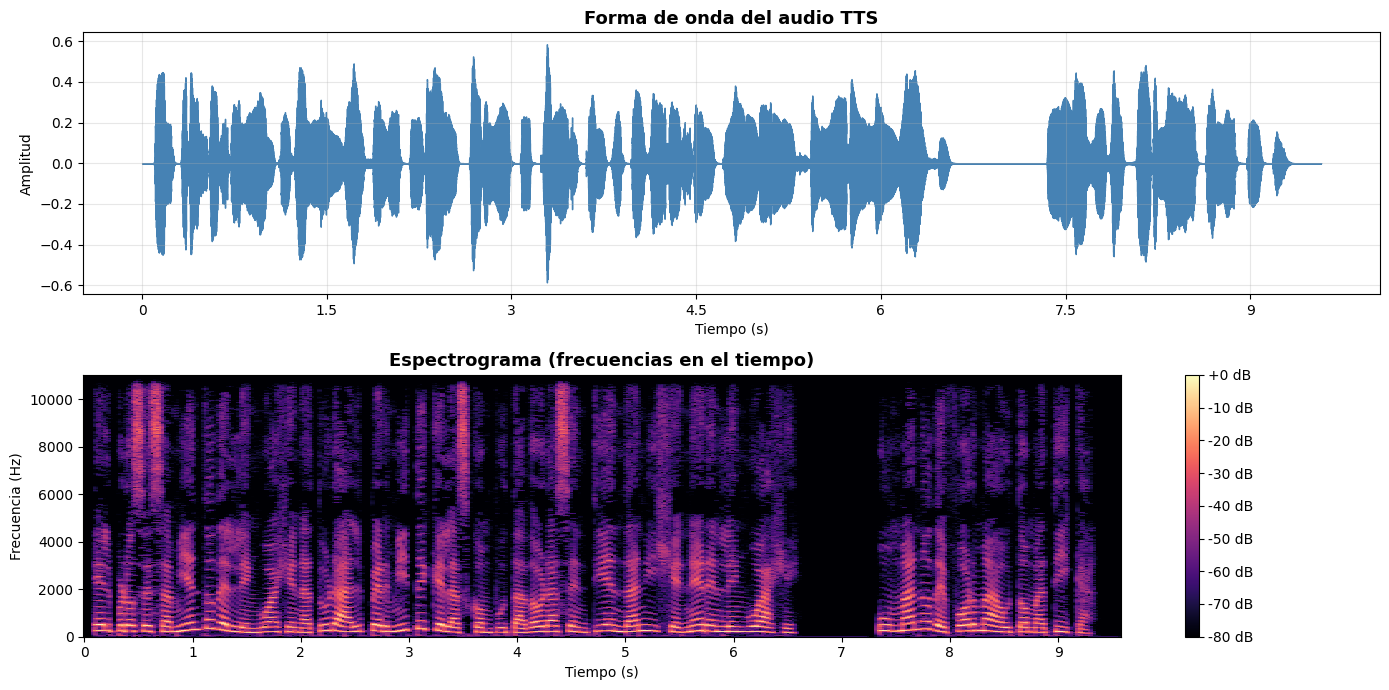


Duracion: 9.58 s | Frecuencia de muestreo: 22050 Hz


In [23]:
# !pip install librosa matplotlib
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
from gtts import gTTS
from IPython.display import Audio, display

texto = "El procesamiento del lenguaje natural permite que las computadoras entiendan y generen lenguaje humano de forma automatica."
tts = gTTS(text=texto, lang='es')
tts.save("nlp_intro.mp3")

print("Texto:", texto)
display(Audio("nlp_intro.mp3"))

# Carga y visualizacion
y, sr = librosa.load("nlp_intro.mp3")

fig, axes = plt.subplots(2, 1, figsize=(14, 7))

# Forma de onda
librosa.display.waveshow(y, sr=sr, ax=axes[0], color='steelblue')
axes[0].set_title("Forma de onda del audio TTS", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Tiempo (s)")
axes[0].set_ylabel("Amplitud")
axes[0].grid(True, alpha=0.3)

# Espectrograma
D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
img = librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='hz', ax=axes[1], cmap='magma')
axes[1].set_title("Espectrograma (frecuencias en el tiempo)", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Tiempo (s)")
axes[1].set_ylabel("Frecuencia (Hz)")
fig.colorbar(img, ax=axes[1], format='%+2.0f dB')

plt.tight_layout()
plt.show()

print(f"\nDuracion: {len(y)/sr:.2f} s | Frecuencia de muestreo: {sr} Hz")

### Ejemplo practico 9.3: Pipeline traduccion + TTS

Combinamos deteccion de idioma, traduccion y TTS para construir un **lector multilingue**: dado texto en cualquier idioma, lo detecta, traduce y narra en espanol.

In [24]:
from langdetect import detect, DetectorFactory
from deep_translator import GoogleTranslator
from gtts import gTTS
from IPython.display import Audio, display

DetectorFactory.seed = 0

def lector_multilingue(texto, idioma_destino='es'):
    """Pipeline: deteccion → traduccion → TTS."""
    # 1. Deteccion
    idioma_origen = detect(texto)
    print(f"Idioma detectado: {idioma_origen}")

    # 2. Traduccion
    if idioma_origen != idioma_destino:
        texto_trad = GoogleTranslator(source=idioma_origen, target=idioma_destino).translate(texto)
        print(f"Traducido [{idioma_origen}→{idioma_destino}]: {texto_trad}")
    else:
        texto_trad = texto
        print(f"Ya en idioma destino: {texto_trad}")

    # 3. TTS
    fname = f"output_{idioma_destino}.mp3"
    gTTS(text=texto_trad, lang=idioma_destino).save(fname)
    print(f"Audio: {fname}")
    display(Audio(fname))
    return texto_trad

# Prueba con varios idiomas
pruebas = [
    "Artificial intelligence is revolutionizing the way we process information.",
    "Les reseaux de neurones profonds apprennent des representations hierarchiques.",
    "Die Verarbeitung naturlicher Sprache ist ein spannendes Forschungsgebiet.",
]

for texto in pruebas:
    print("=" * 60)
    print(f"Original: {texto}")
    lector_multilingue(texto, idioma_destino='es')
    print()

Original: Artificial intelligence is revolutionizing the way we process information.
Idioma detectado: en
Traducido [en→es]: La inteligencia artificial está revolucionando la forma en que procesamos la información.
Audio: output_es.mp3



Original: Les reseaux de neurones profonds apprennent des representations hierarchiques.
Idioma detectado: fr
Traducido [fr→es]: Las redes neuronales profundas aprenden representaciones jerárquicas.
Audio: output_es.mp3



Original: Die Verarbeitung naturlicher Sprache ist ein spannendes Forschungsgebiet.
Idioma detectado: de
Traducido [de→es]: El procesamiento del lenguaje natural es un área de investigación apasionante.
Audio: output_es.mp3


### Ejercicio 9.1: Lector de noticias TTS

Implementa un **lector de noticias** que:

```python
titulares = [
    "La inteligencia artificial supera a los medicos en diagnostico de cancer de piel.",
    "El Banco Central eleva la tasa de interes por segunda vez en el anio.",
    "Argentina clasifica para la Copa del Mundo con una goleada historica.",
    "Cientificos descubren nueva especie de dinosaurio en la Patagonia.",
    "El precio del petroleo cae un 5 por ciento tras el acuerdo de la OPEC.",
]
```

**Tareas:**
1. Genera un archivo MP3 por cada titular (`noticia_1.mp3`, `noticia_2.mp3`, etc.).
2. Genera un archivo resumen con todos los titulares encadenados (separados por `" ... "`).
3. Usa `librosa` para mostrar la duracion de cada archivo generado.
4. Muestra todos los audios en el notebook con `IPython.display.Audio`.

### Ejercicio 9.2: Pipeline completo: deteccion → traduccion → sentimiento → TTS

```python
resenas = [
    "This movie is absolutely breathtaking. The visual effects are stunning!",
    "Un chef-d'oeuvre cinematographique. Je n'ai pas pu retenir mes larmes.",
    "Die schauspielerischen Leistungen sind herausragend. Sehr empfehlenswert!",
    "Una pelicula increible. La actuacion de los protagonistas es impecable.",
    "Il film e commovente e profondo. Una delle migliori opere dell'anno.",
]
```

**Tareas:**
1. Detecta el idioma de cada reseña.
2. Traduce cada reseña al espanol.
3. Analiza el sentimiento (usando `sentiment-analysis-spanish` o el modelo BERT multilingue).
4. Genera un audio por reseña con el texto: `"Reseña [n] en [idioma]. Sentimiento: [positivo/negativo]. [texto_es]"`.
5. Muestra tabla resumen: idioma original, texto_es, sentimiento, archivo de audio.

---

## 10. Modelado de Topicos (Topic Modeling)

### Fundamento teorico

El **modelado de topicos** es una tecnica de aprendizaje no supervisado que descubre temas latentes en un corpus de documentos sin necesidad de datos etiquetados.

#### Modelos clasicos: LDA y NMF

**Latent Dirichlet Allocation (LDA)** (Blei, Ng y Jordan, 2003): Modelo generativo que asume que cada documento es una mezcla de topicos y cada topico es una distribucion de probabilidad sobre palabras. Usa el enfoque **Bag-of-Words (BoW)**.

**Non-negative Matrix Factorization (NMF)**: Descompone la matriz documento-termino en dos matrices no negativas. Tiende a producir topicos mas coherentes e interpretables que LDA.

**Limitacion clave de LDA y NMF:** Al usar BoW, ignoran el orden y el significado contextual de las palabras.

#### Enfoques modernos basados en embeddings

**BERTopic** y **Top2Vec** usan sentence embeddings semanticos. El pipeline tipico es:

1. **Embeddings:** Cada documento → vector semantico (Sentence-BERT).
2. **Reduccion dimensional:** UMAP reduce de ~768 a 5-15 dimensiones.
3. **Clustering:** HDBSCAN agrupa documentos semanticamente similares.
4. **Representacion:** c-TF-IDF extrae palabras discriminantes de cada cluster.

| Modelo | Enfoque | Ventaja principal |
|--------|---------|-------------------|
| LDA | BoW + Dirichlet | Simple e interpretable |
| NMF | BoW + Algebra lineal | Topicos coherentes |
| BERTopic | Embeddings + HDBSCAN | Captura semantica, state-of-the-art |
| Top2Vec | Embeddings + HDBSCAN | No requiere stopwords ni stemming |

### Ejemplo practico 10.1: LDA con scikit-learn

Aplicamos **Latent Dirichlet Allocation** sobre un corpus de noticias para descubrir 4 topicos.

Vocabulario: 170 terminos | Matriz: (24, 170)

=== Topicos LDA (top 8 palabras) ===
Topico 1: las, para, la, reducir, el, record, carbono, resolver
Topico 2: el, los, de, gano, con, del, pais, millones
Topico 3: el, de, un, en, los, por, nuevo, miles
Topico 4: de, la, el, los, al, inflacion, empresa, modelos

=== Asignacion por documento ===
[T2 p=0.94] El equipo argentino gano el partido de futbol con tres goles
[T3 p=0.94] El tenista espanol gano el torneo de Roland Garros con gran 
[T2 p=0.94] El ciclista colombiano gano la vuelta al pais con amplia ven
[T2 p=0.94] El club barcelones ficho a un nuevo delantero por 80 millone
[T2 p=0.94] Los Juegos Olimpicos reuniran a los mejores atletas del mund
[T3 p=0.92] El corredor keniano rompio el record mundial de maraton.
[T3 p=0.93] La empresa tecnologica lanzo un nuevo modelo de inteligencia
[T4 p=0.94] Los modelos de lenguaje de gran escala transforman la indust
[T1 p=0.93] La computacion cuantica promete resolver problemas imposible
[T3

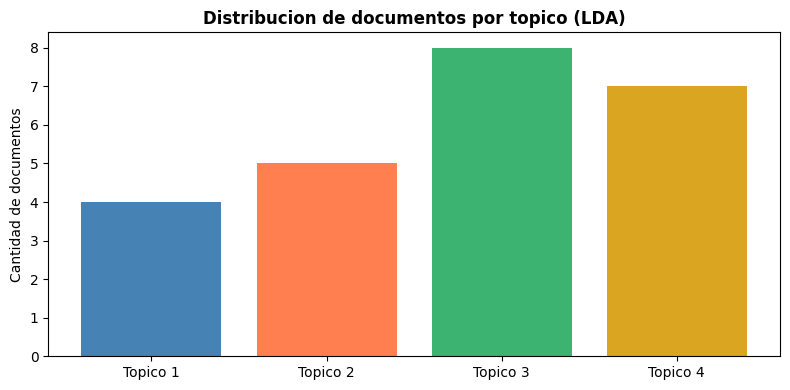

In [25]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt

# Corpus con 4 categorias implicitas: deportes, tecnologia, clima, economia
documentos = [
    # Deportes
    "El equipo argentino gano el partido de futbol con tres goles.",
    "El tenista espanol gano el torneo de Roland Garros con gran autoridad.",
    "El ciclista colombiano gano la vuelta al pais con amplia ventaja.",
    "El club barcelones ficho a un nuevo delantero por 80 millones de euros.",
    "Los Juegos Olimpicos reuniran a los mejores atletas del mundo en Paris.",
    "El corredor keniano rompio el record mundial de maraton.",
    # Tecnologia
    "La empresa tecnologica lanzo un nuevo modelo de inteligencia artificial.",
    "Los modelos de lenguaje de gran escala transforman la industria del software.",
    "La computacion cuantica promete resolver problemas imposibles para ordenadores clasicos.",
    "El nuevo chip supera en rendimiento a todos los modelos anteriores.",
    "Las redes neuronales profundas aprenden representaciones complejas de los datos.",
    "La startup de robotica presento su ultimo robot autonomo de servicio.",
    # Cambio climatico
    "El cambio climatico aumenta la frecuencia de desastres naturales en el planeta.",
    "Las temperaturas globales alcanzaron un record historico el verano pasado.",
    "La cumbre climatica internacional busca reducir las emisiones de carbono.",
    "Los oceanos absorben el exceso de calor y dioxido de carbono atmosferico.",
    "Los glaciares retroceden a un ritmo alarmante debido al calentamiento global.",
    "Las energias renovables son clave para reducir el impacto ambiental.",
    # Economia
    "El banco central subio la tasa de interes para controlar la inflacion.",
    "El mercado de valores registro fuertes caidas tras los datos de inflacion.",
    "Las exportaciones del pais crecieron un diez por ciento en el trimestre.",
    "La empresa reporto ganancias record gracias al aumento de ventas digitales.",
    "El gobierno anuncio un plan de inversion en infraestructura por miles de millones.",
    "Los analistas economicos pronostican una recuperacion gradual para el proximo anio.",
]

# Vectorizacion Bag-of-Words
vectorizer = CountVectorizer(max_df=0.9, min_df=1)
X = vectorizer.fit_transform(documentos)
feature_names = vectorizer.get_feature_names_out()
print(f"Vocabulario: {len(feature_names)} terminos | Matriz: {X.shape}")

# LDA
n_topicos = 4
lda = LatentDirichletAllocation(n_components=n_topicos, random_state=42, max_iter=20)
lda.fit(X)

# Top palabras por topico
print(f"\n=== Topicos LDA (top 8 palabras) ===")
for i, topic in enumerate(lda.components_):
    top_idx = topic.argsort()[-8:][::-1]
    top_words = [feature_names[j] for j in top_idx]
    print(f"Topico {i+1}: {', '.join(top_words)}")

# Asignacion de topicos a documentos
doc_topic = lda.transform(X)
print(f"\n=== Asignacion por documento ===")
for i, doc in enumerate(documentos):
    t = doc_topic[i].argmax() + 1
    p = doc_topic[i].max()
    print(f"[T{t} p={p:.2f}] {doc[:60]}")

# Grafico de distribucion
topicos_asignados = [doc_topic[i].argmax() + 1 for i in range(len(documentos))]
conteo = Counter(topicos_asignados)
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar([f"Topico {k}" for k in sorted(conteo)],
       [conteo[k] for k in sorted(conteo)],
       color=['steelblue', 'coral', 'mediumseagreen', 'goldenrod'])
ax.set_title("Distribucion de documentos por topico (LDA)", fontweight='bold')
ax.set_ylabel("Cantidad de documentos")
plt.tight_layout()
plt.show()

### Ejemplo practico 10.2: NMF y comparacion con LDA

**NMF** usa TF-IDF como entrada (no CountVectorizer) y algebra lineal para factorizar la matriz. Suele producir topicos mas coherentes. Comparamos ambos metodos sobre el mismo corpus.

In [ ]:
from sklearn.decomposition import NMF
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

# NMF con TF-IDF
tfidf_vec = TfidfVectorizer(max_df=0.9, min_df=1)
X_tfidf = tfidf_vec.fit_transform(documentos)
feature_names_tfidf = tfidf_vec.get_feature_names_out()

nmf = NMF(n_components=4, random_state=42, init='nndsvda')
W = nmf.fit_transform(X_tfidf)  # W: documentos x topicos
H = nmf.components_              # H: topicos x terminos

print("=== Topicos NMF (top 8 palabras) ===")
for i, topic in enumerate(H):
    top_idx = topic.argsort()[-8:][::-1]
    top_words = [feature_names_tfidf[j] for j in top_idx]
    print(f"Topico {i+1}: {', '.join(top_words)}")

# Comparacion LDA vs NMF
print("\n=== Comparacion de asignacion de topicos ===")
filas = []
for i, doc in enumerate(documentos):
    t_lda = doc_topic[i].argmax() + 1
    t_nmf = W[i].argmax() + 1
    filas.append({
        'Documento': doc[:55] + '...',
        'LDA': f"T{t_lda}",
        'NMF': f"T{t_nmf}",
        'Coinciden': 'Si' if t_lda == t_nmf else 'No'
    })
df = pd.DataFrame(filas)
print(df.to_string(index=False))

n_coincide = sum(1 for f in filas if f['Coinciden'] == 'Si')
print(f"\nCoincidencia: {n_coincide}/{len(documentos)} ({n_coincide/len(documentos)*100:.0f}%)")

=== Topicos NMF (top 8 palabras) ===
Topico 1: en, por, un, millones, el, nuevo, de, del
Topico 2: el, gano, con, futbol, equipo, argentino, partido, goles
Topico 3: de, la, los, para, inflacion, carbono, datos, el
Topico 4: record, empresa, al, un, reporto, ventas, ganancias, gracias

=== Comparacion de asignacion de topicos ===
                                                 Documento LDA NMF Coinciden
El equipo argentino gano el partido de futbol con tres ...  T2  T2        Si
El tenista espanol gano el torneo de Roland Garros con ...  T3  T2        No
El ciclista colombiano gano la vuelta al pais con ampli...  T2  T2        Si
El club barcelones ficho a un nuevo delantero por 80 mi...  T2  T1        No
Los Juegos Olimpicos reuniran a los mejores atletas del...  T2  T1        No
El corredor keniano rompio el record mundial de maraton...  T3  T4        No
La empresa tecnologica lanzo un nuevo modelo de intelig...  T3  T4        No
Los modelos de lenguaje de gran escala transforman l

### Ejemplo practico 10.3: BERTopic sobre corpus de noticias

**BERTopic** combina sentence embeddings con UMAP + HDBSCAN + c-TF-IDF para un modelado de topicos semantico. Usamos `fetch_20newsgroups` de scikit-learn.

In [ ]:
# !pip install bertopic sentence-transformers
from sklearn.datasets import fetch_20newsgroups
from sentence_transformers import SentenceTransformer
from bertopic import BERTopic
import pandas as pd

# Dataset: 4 categorias del benchmark 20 newsgroups
categorias = ['sci.space', 'rec.sport.baseball', 'comp.graphics', 'talk.politics.misc']
ng = fetch_20newsgroups(subset='train', categories=categorias, remove=('headers', 'footers', 'quotes'))

# Filtramos documentos muy cortos y tomamos 400 para agilizar
docs = [d for d in ng.data if len(d.strip()) > 80][:400]
print(f"Documentos para modelado: {len(docs)}")
print(f"Categorias: {categorias}")
print(f"\nEjemplo:\n{docs[0][:250]}...")

Documentos para modelado: 400
Categorias: ['sci.space', 'rec.sport.baseball', 'comp.graphics', 'talk.politics.misc']

Ejemplo:

And the religious right worships engines, smokestacks, landfills,
and hates people.

What does this name-calling have to do with anything you are claiming about
the truth of environmental disaster?  Nothing that I have read in this
thread, nor heard...


In [ ]:
# Paso 1: Pre-calcular embeddings (recomendado hacerlo una sola vez)
embedding_model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')
embeddings = embedding_model.encode(docs, show_progress_bar=True)
print(f"Embeddings generados: {embeddings.shape}")

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/13 [00:00<?, ?it/s]

Embeddings generados: (400, 384)


In [ ]:
# Paso 2: Entrenar BERTopic
topic_model = BERTopic(
    embedding_model=embedding_model,
    min_topic_size=10,
    nr_topics='auto',
    verbose=True
)
topics, probs = topic_model.fit_transform(docs, embeddings)

# Resumen de topicos
info = topic_model.get_topic_info()
print("\n=== Topicos descubiertos por BERTopic ===")
print(info[info['Topic'] != -1][['Topic', 'Count', 'Name']].to_string(index=False))

print("\n=== Palabras clave por topico ===")
for tid in sorted(topic_model.get_topics().keys()):
    if tid == -1:
        continue
    palabras = [p[0] for p in topic_model.get_topic(tid)[:8]]
    print(f"Topico {tid}: {', '.join(palabras)}")

outliers = topics.count(-1)
print(f"\nOutliers (topico -1): {outliers}/{len(docs)} docs ({outliers/len(docs)*100:.1f}%)")

2026-04-23 18:05:12,298 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-23 18:05:23,230 - BERTopic - Dimensionality - Completed ✓
2026-04-23 18:05:23,232 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-23 18:05:23,251 - BERTopic - Cluster - Completed ✓
2026-04-23 18:05:23,252 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-04-23 18:05:23,349 - BERTopic - Representation - Completed ✓
2026-04-23 18:05:23,350 - BERTopic - Topic reduction - Reducing number of topics
2026-04-23 18:05:23,359 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-23 18:05:23,444 - BERTopic - Representation - Completed ✓
2026-04-23 18:05:23,446 - BERTopic - Topic reduction - Reduced number of topics from 5 to 5



=== Topicos descubiertos por BERTopic ===
 Topic  Count              Name
     0     97   0_the_to_of_and
     1     96 1_the_to_and_that
     2     93   2_the_and_is_to
     3     78   3_the_of_to_and

=== Palabras clave por topico ===
Topico 0: the, to, of, and, that, in, it, is
Topico 1: the, to, and, that, in, of, he, is
Topico 2: the, and, is, to, of, jpeg, image, for
Topico 3: the, of, to, and, space, for, in, is

Outliers (topico -1): 36/400 docs (9.0%)


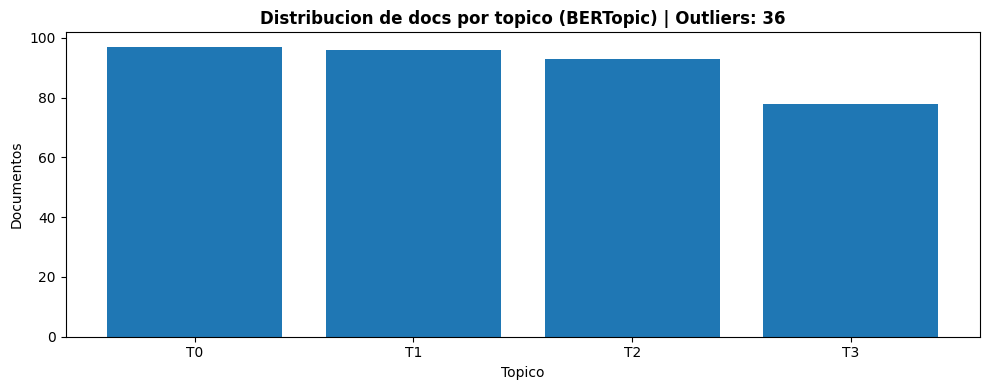


=== Docs representativos del Topico 0 ===
Doc 1: 
       There are a couple of ways to look at them.  One is, "We want
you to support this Constitution, so we'll say anything that we think
will appeal to you," or the more straightforward, "This is w...

Doc 2: THE WHITE HOUSE

                    Office of the Press Secretary
______________________________________________________________
For Immediate Release                             April 15, 1993     
...



In [ ]:
import matplotlib.pyplot as plt
from collections import Counter

# Distribucion de documentos por topico
conteo = Counter([t for t in topics if t != -1])
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar([f"T{k}" for k in sorted(conteo.keys())],
       [conteo[k] for k in sorted(conteo.keys())])
ax.set_title(f"Distribucion de docs por topico (BERTopic) | Outliers: {topics.count(-1)}",
             fontweight='bold')
ax.set_xlabel("Topico")
ax.set_ylabel("Documentos")
plt.tight_layout()
plt.show()

# Documentos representativos del topico mas grande
topico_mayor = max(conteo, key=conteo.get)
rep_docs = topic_model.get_representative_docs(topico_mayor)
print(f"\n=== Docs representativos del Topico {topico_mayor} ===")
for i, doc in enumerate(rep_docs[:2]):
    print(f"Doc {i+1}: {doc[:200]}...\n")

### Ejercicio 10.1: Modelado de topicos sobre noticias en espanol

```python
noticias = [
    # Salud
    "Investigadores descubrieron una nueva vacuna contra el dengue con alta eficacia.",
    "El ministerio de salud anuncio campanas masivas de vacunacion para el invierno.",
    "Un nuevo tratamiento contra el cancer de pulmon mostro resultados prometedores.",
    "Los hospitales publicos registraron record de consultas por enfermedades respiratorias.",
    "La telemedicina crecio un 300 por ciento durante la pandemia y continua en auge.",
    "Cientificos argentinos desarrollaron un biosensor para detectar diabetes en minutos.",
    # Educacion
    "El gobierno aumento el presupuesto educativo en un 20 por ciento para el proximo anio.",
    "Universidades implementaron programas de inteligencia artificial en sus curriculos.",
    "La educacion digital se consolida como herramienta clave en las aulas modernas.",
    "Miles de estudiantes accedieron a becas internacionales gracias a nuevos convenios.",
    "El nivel de lectoescritura mejoro en escuelas que adoptaron metodologias activas.",
    "Investigadores evaluaron el impacto del bilinguismo en el desarrollo cognitivo.",
    # Medio ambiente
    "La deforestacion en el Amazonas alcanzo niveles record durante el ultimo trimestre.",
    "Organizaciones ambientalistas exigen medidas urgentes contra la contaminacion del aire.",
    "Un nuevo acuerdo internacional busca proteger el 30 por ciento de los oceanos.",
    "Las ciudades mas verdes del mundo reducen emisiones con transporte electrico masivo.",
    "Cientificos alertan sobre la extincion masiva de especies marinas por la acidificacion.",
    "El litio tiene alto valor estrategico pero su extraccion genera controversia ambiental.",
    # Cultura
    "El festival de cine latinoamericano convoco a miles de espectadores en 2024.",
    "Una novela argentina gano el premio literario mas importante de habla hispana.",
    "El museo de arte moderno inauguro una exposicion de artistas emergentes locales.",
    "La musica folclorica fue reconocida como patrimonio cultural inmaterial de la nacion.",
    "El boom del podcast en espanol democratiza el acceso a contenido cultural diverso.",
    "Un director de teatro local recibio financiamiento para llevar su obra a Europa.",
]
```

**Tareas:**
1. Aplica **LDA** con `n_components=4`. Identifica a que categoria corresponde cada topico segun sus palabras clave.
2. Aplica **NMF** con los mismos parametros usando `TfidfVectorizer`. Compara palabras clave con LDA.
3. Asigna cada documento a su topico dominante y evalua cuantos se asignaron correctamente.
4. Genera un grafico de distribucion de topicos para ambos metodos.

### Ejercicio 10.2: Efecto del numero de topicos en LDA

Usando el corpus del Ejercicio 10.1:

1. Entrena modelos LDA con `n_components` en `[2, 3, 4, 5, 6, 8]`.
2. Para cada modelo, calcula la **perplejidad** (`lda.perplexity(X)`) sobre el corpus de entrenamiento. Menor perplejidad = mejor ajuste.
3. Grafica la perplejidad en funcion del numero de topicos.
4. ¿Que numero de topicos minimiza la perplejidad? ¿Coincide con las 4 categorias reales?
5. Muestra las palabras clave del modelo con el numero optimo de topicos.

### Ejercicio 10.3: BERTopic en espanol

Descarga el siguiente dataset de titulares de noticias en espanol:

```python
from datasets import load_dataset
dataset = load_dataset("Nicky0007/titulos_noticias_rcn_clasificadas")
titulos = [d for d in dataset['train']['text'][:1000] if len(d) > 20]
```

**Tareas:**
1. Pre-calcula embeddings con `SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')`.
2. Entrena BERTopic con `min_topic_size=15`.
3. Muestra los topicos descubiertos con sus palabras clave.
4. Para los 3 topicos mas grandes, muestra los 2 titulares mas representativos.
5. ¿Que porcentaje de documentos quedo como outlier?
6. Grafica la distribucion de documentos por topico.

---

## Ejercicios integradores (Parte 2)

Los siguientes ejercicios combinan tecnicas de las secciones 7 a 10 con las de la Parte 1 (NER, sentiment analysis, busqueda semantica, frases sustantivas). Representan escenarios reales de aplicacion.

### Ejercicio integrador 4: Pipeline multilingue de analisis de resenas

Una plataforma de e-commerce internacional recibe resenas en multiples idiomas. Construi un pipeline completo:

```python
resenas_internacionales = [
    "Producto increible! Llego en perfectas condiciones y antes de lo esperado.",
    "This product is terrible. It broke after just two days of use. Very disappointed.",
    "Produit de tres bonne qualite, je suis tres satisfait. Livraison rapide!",
    "Das Produkt ist genau wie beschrieben. Gute Qualitat fur den Preis.",
    "Ottimo prodotto! Funziona perfettamente, consiglio vivamente a tutti.",
    "Produto chegou danificado. Muito insatisfeito com a qualidade do embalamento.",
    "Excelente relacion calidad-precio. El material es resistente y duradero.",
    "The delivery was slow and the product does not match the description at all.",
    "Je suis decu par ce produit. La qualite laisse beaucoup a desirer.",
    "Sehr enttauschend. Das Produkt sieht billig aus und funktioniert nicht.",
]
```

**Pipeline a implementar:**

1. **Deteccion de idioma** (Sec. 7): Detecta el idioma de cada resena con `ftlangdetect`.
2. **Traduccion** (Sec. 8): Traduce al espanol las resenas que no lo esten con `GoogleTranslator`.
3. **Analisis de sentimiento** (Parte 1, Sec. 5): Analiza cada resena traducida con el modelo BERT multilingue.
4. **Frases sustantivas** (Parte 1, Sec. 1): Extrae las 5 frases nominales mas frecuentes del corpus traducido con spaCy.
5. **TTS** (Sec. 9): Genera audio con el resumen: `"De X resenas analizadas, Y son positivas y Z son negativas. Los temas mas mencionados son: [frases top]."`.

**Salida esperada:**
- DataFrame: `idioma`, `resena_original`, `resena_traducida`, `sentimiento`, `score`.
- Lista de 5 frases sustantivas mas frecuentes.
- Archivo MP3 con el resumen narrado.

### Ejercicio integrador 5: Sistema de inteligencia sobre noticias

Construi un **sistema de analisis de noticias** que combine modelado de topicos, NER y busqueda semantica:

```python
corpus_noticias = [
    "El presidente de Argentina anuncio un plan de modernizacion del sistema de salud publica.",
    "La seleccion argentina de futbol gano el partido clasificatorio ante Brazil por 3 a 1.",
    "Google inauguro su nuevo centro de datos en Santiago de Chile con inversion de 200 millones.",
    "Investigadores de la UBA descubrieron una molecula que podria combatir el cancer de pancreas.",
    "La inflacion en Argentina supero el 100 por ciento interanual segun datos del INDEC.",
    "Messi fue reconocido como el mejor jugador del mundo por octava vez en el Balon de Oro.",
    "Microsoft adquirio la empresa de IA OpenAI con una inversion de 10 mil millones de dolares.",
    "El Ministerio de Educacion lanzo becas para estudiantes universitarios de bajos recursos.",
    "Cientificos de NASA descubrieron evidencia de agua liquida en la superficie de Marte.",
    "El dolar supero los 1000 pesos en el mercado informal, generando alarma entre economistas.",
    "Real Madrid gano la Champions League por decimo cuarta vez ante el Borussia Dortmund.",
    "Apple presento el nuevo iPhone con chip de inteligencia artificial integrado.",
    "El hospital Garrahan recibio equipamiento medico de ultima generacion de paises europeos.",
    "La tormenta Ciaran causo destrozos en Francia e Italia con vientos de 200 km por hora.",
    "Carlos Alcaraz gano el US Open por segunda vez consecutiva ante Novak Djokovic.",
]
```

**Sistema a construir:**

1. **LDA** (Sec. 10) con 4 topicos. Asigna un nombre descriptivo a cada topico.

2. **NER por topico** (Parte 1, Sec. 3): Para cada topico, aplica NER con spaCy a las noticias asignadas. Crea un resumen de las entidades mas frecuentes por tipo (PER, ORG, LOC).

3. **Busqueda semantica** (Parte 1, Sec. 6): Motor de busqueda sobre el corpus con `SentenceTransformer`. El usuario hace una consulta y obtiene las noticias mas relevantes con su topico.

4. **Integracion**: Dada una consulta:
   - Encuentra las 3 noticias mas relevantes.
   - Identifica a que topico pertenece cada resultado.
   - Extrae las entidades nombradas de los resultados.
   - Genera un resumen narrado (TTS) con: `"Se encontraron X noticias sobre '[consulta]'. Topico principal: '[nombre]'. Entidades: [lista]."`.

Prueba con: `"economia y finanzas"`, `"deporte y competencias"`, `"ciencia y tecnologia"`.

### Ejercicio integrador 6: Asistente de contenido multilingue

Diseña un **asistente de contenido** completo que integre todas las tecnicas:

```python
docs_ia = [
    "Artificial intelligence is transforming every industry, from healthcare to finance.",
    "Die kunstliche Intelligenz revolutioniert die Art und Weise, wie wir arbeiten.",
    "L'intelligence artificielle change radicalement notre facon de traiter l'information.",
    "La inteligencia artificial esta redefiniendo los limites en la medicina moderna.",
    "Machine learning models require vast amounts of labeled data to achieve high accuracy.",
    "Les reseaux de neurones profonds apprennent des representations hierarchiques.",
    "Los modelos de lenguaje de gran escala como GPT generan texto de alta calidad.",
    "Natural language processing enables computers to understand and generate human language.",
    "Das maschinelle Lernen ermoglicht es Computern, aus Erfahrung zu lernen.",
    "La reconnaissance d'images est une application majeure de l'apprentissage profond.",
    "El procesamiento del lenguaje natural permite analizar millones de textos automaticamente.",
    "Computer vision systems can now identify objects with superhuman accuracy.",
]
```

**Tareas:**

1. **Deteccion y estadisticas** (Sec. 7): Detecta el idioma de cada doc. Muestra distribucion de idiomas.

2. **Normalizacion al espanol** (Sec. 8): Traduce todos los docs que no esten en espanol.

3. **Analisis del corpus normalizado:**
   - NMF con 3 topicos sobre el corpus en espanol.
   - 5 frases sustantivas mas frecuentes con spaCy.
   - NER: entidades de tipo ORG y MISC mas mencionadas.

4. **Busqueda semantica multilingue** (Parte 1, Sec. 6 + Sec. 8): El usuario puede buscar en cualquier idioma:
   - Detecta el idioma de la consulta.
   - Si no es espanol, la traduce.
   - Busca en el corpus normalizado.
   - Devuelve los 3 docs mas similares en espanol y en el idioma original.

5. **Resumen narrado** (Sec. 9): Genera un audio en espanol con el resumen del corpus: cuantos docs, en que idiomas, cuales son los topicos y que entidades se mencionan.

Prueba la busqueda con: `"deep learning"` (en), `"redes neuronales"` (es), `"apprentissage automatique"` (fr).

---

**Fin de la practica - Parte 2.**

Esta practica cubrio las tecnicas de:

- **Deteccion de idioma** con `langdetect` y `ftlangdetect`
- **Traduccion automatica** con MarianMT (HuggingFace) y `deep-translator`
- **Sintesis de voz** con `gTTS` y visualizacion con `librosa`
- **Modelado de topicos** con LDA, NMF y BERTopic

Combinadas con las tecnicas de la Parte 1, forman un conjunto de herramientas poderoso para construir sistemas NLP reales y multilingues.